# Simulation des Bacs de Soufre Solide et Liquide

**Nouveautes :**
- Trains partent **quoi qu'il arrive** (soutirage force)
- Stock solide maintenu entre **4000 et 18000 tonnes** (bateaux ajoutes automatiquement)
- **Annulations de trains** : 1 sur 12 (8.33%)
- **Arrets de fonte** : probabilite 10% (debit = 0)
- Stock liquide vise entre **3000 et 15000 tonnes** (facteur multiplicatif sur la fonte)
- **Tailles de bateaux** : 4000, 5000, 7000, 8000, 12000 (70% sont 5000 ou 7000)
- **Conditionnement** : Si stock liquide > 10000t, on reduit/blque les appros de bateaux

## 1. Configuration et Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import seaborn as sns
from scipy.stats import truncnorm
import os
import json

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
np.random.seed(42)
print("Configuration terminee")

Configuration terminee


## 2. Parametres

In [2]:
N_JOURS = 365
STOCK_SOLIDE_INITIAL = 1000
STOCK_LIQUIDE_INITIAL = 8000
STOCK_SOLIDE_MIN = 2000
STOCK_SOLIDE_MAX = 18000
STOCK_LIQUIDE_MIN = 3000
STOCK_LIQUIDE_MAX = 15000
NB_BATEAUX_CHER = 1

# Seuil pour conditionner les appros de bateaux
# Si stock liquide > SEUIL_LIQUIDE_BLOQUE, on ne commande pas de bateau
SEUIL_LIQUIDE_BLOQUE = 5000

CAPACITE_SOLIDE = 20000
CAPACITE_LIQUIDE = 16000

# Tailles de bateaux possibles (70% sont 5000 ou 7000)
TAILLES_BATEAUX = [1000, 4000, 5000, 7000, 8000, 12000]
# 70% pour 5000 et 7000 (35% chacun), 30% pour 4000, 8000, 12000 (10% chacun)
PROBA_TAILLES = [0.07,0.08 , 0.40, 0.35, 0.04, 0.06]

DEBIT_MIN = 250
DEBIT_MAX = 750
DEBIT_MOYEN = 500
DEBIT_ECART_TYPE = 150
TAILLE_MIN_TRAIN = 650
TAILLE_MAX_TRAIN = 750
JOURS_SOUTIRAGE = [1, 2, 3, 5]
PROBA_ANNULATION_TRAIN = 1/12
PROBA_ARRET_FONTE = 0.1

lower = (DEBIT_MIN - DEBIT_MOYEN) / DEBIT_ECART_TYPE
upper = (DEBIT_MAX - DEBIT_MOYEN) / DEBIT_ECART_TYPE
debit_distribution = truncnorm(lower, upper, loc=DEBIT_MOYEN, scale=DEBIT_ECART_TYPE)

## 3. Fonctions

In [3]:
def choisir_taille_bateau():
    return np.random.choice(TAILLES_BATEAUX, p=PROBA_TAILLES)

In [4]:
def doit_commander_bateau(stock_solide, stock_liquide):
    if stock_solide >= STOCK_SOLIDE_MIN:
        return False
    if stock_liquide > SEUIL_LIQUIDE_BLOQUE:
        return False
    return True

In [5]:
def calculer_facteur_liquide(stock_liquide):
    if stock_liquide < STOCK_LIQUIDE_MIN:
        return 1 + 0.5 * ((STOCK_LIQUIDE_MIN - stock_liquide) / STOCK_LIQUIDE_MIN)
    elif stock_liquide > STOCK_LIQUIDE_MAX:
        return 1 - 0.5 * ((stock_liquide - STOCK_LIQUIDE_MAX) / STOCK_LIQUIDE_MAX)
    else:
        return 1.0

In [6]:
def generer_soutirages_trains(n_jours, jours_soutirage, taille_min, taille_max, proba_annulation):
    jours = []
    quantites = []
    statuts = []
    for jour in range(1, n_jours + 1):
        jour_semaine = (jour - 1) % 7 + 1
        if jour_semaine in jours_soutirage:
            quantite = np.random.randint(taille_min, taille_max + 1)
            if np.random.random() < proba_annulation:
                statuts.append('annule')
                quantites.append(0)
            else:
                statuts.append('reussi')
                quantites.append(quantite)
            jours.append(jour)
    return pd.DataFrame({'jour': jours, 'quantite': quantites, 'statut': statuts}).sort_values('jour').reset_index(drop=True)

In [7]:
def generer_debits_liquefaction(n_jours, distribution, proba_arret):
    debits = distribution.rvs(size=n_jours)
    mask_arret = np.random.random(n_jours) < proba_arret
    debits[mask_arret] = 0
    return debits

In [8]:
def simuler_systeme(n_jours, stock_solide_initial, stock_liquide_initial,
                   capacite_solide, capacite_liquide,
                   stock_solide_min, stock_solide_max,
                   debits_base, soutirages,
                   cout_fusion=65, prix_solide_initial=100, prix_liquide_initial=165,
                   prix_bateau_initial=700, taux_decroissance=0.2, prix_minimal=100):
    jours = list(range(1, n_jours + 1))
    stock_solide = np.zeros(n_jours + 1)
    stock_liquide = np.zeros(n_jours + 1)
    cout_moyen_solide = np.zeros(n_jours + 1)
    cout_moyen_liquide = np.zeros(n_jours + 1)
    
    stock_solide[0] = stock_solide_initial
    stock_liquide[0] = stock_liquide_initial
    cout_moyen_solide[0] = prix_solide_initial
    cout_moyen_liquide[0] = prix_liquide_initial
    
    cout_solide_total = stock_solide_initial * prix_solide_initial
    cout_liquide_total = stock_liquide_initial * prix_liquide_initial
    stock_solide_total = stock_solide_initial
    stock_liquide_total = stock_liquide_initial
    
    idx_soutirage = 0
    bateaux_jours = []
    bateaux_quantites = []
    bateaux_prix = []
    bateau_numero = 0
    bateaux_bloques = 0
    
    bateaux_numeros = []
    
    events = {"jour": [], "type": [], "quantite": [], "stock_solide": [], "stock_liquide": [],
              "cout_moyen_solide": [], "cout_moyen_liquide": []}
    
    for jour in range(1, n_jours + 1):
        stock_solide[jour] = stock_solide[jour - 1]
        stock_liquide[jour] = stock_liquide[jour - 1]
        cout_moyen_solide[jour] = cout_moyen_solide[jour - 1]
        cout_moyen_liquide[jour] = cout_moyen_liquide[jour - 1]
        
        if stock_solide[jour] < stock_solide_min:
            if doit_commander_bateau(stock_solide[jour], stock_liquide[jour]):
                bateau_numero += 1
                quantite_bateau = choisir_taille_bateau()
                if bateau_numero <= NB_BATEAUX_CHER:
                    prix_bateau = prix_bateau_initial
                else:
                    prix_bateau = prix_bateau_initial * (1 - taux_decroissance) ** (bateau_numero - NB_BATEAUX_CHER)
                    prix_bateau = max(prix_bateau, prix_minimal)
                espace_disponible = capacite_solide - stock_solide[jour]
                quantite_reelle = min(quantite_bateau, espace_disponible)
                if quantite_reelle > 0:
                    cout_solide_total += quantite_reelle * prix_bateau
                    stock_solide_total += quantite_reelle
                    cout_moyen_solide[jour] = cout_solide_total / stock_solide_total if stock_solide_total > 0 else 0
                    stock_solide[jour] += quantite_reelle
                    bateaux_jours.append(jour)
                    bateaux_quantites.append(quantite_reelle)
                    bateaux_prix.append(prix_bateau)
                    bateaux_numeros.append(bateau_numero)
            else:
                bateaux_bloques += 1
        
        debit_jour = debits_base[jour - 1]
        facteur = calculer_facteur_liquide(stock_liquide[jour])
        debit_ajuste = debit_jour * facteur
        quantite_transfert = min(debit_ajuste, stock_solide[jour])
        espace_liquide = capacite_liquide - stock_liquide[jour]
        quantite_transfert = min(quantite_transfert, espace_liquide)
        if quantite_transfert > 0:
            cout_transfert = cout_moyen_solide[jour] + cout_fusion
            cout_liquide_total += quantite_transfert * cout_transfert
            stock_liquide_total += quantite_transfert
            cout_moyen_liquide[jour] = cout_liquide_total / stock_liquide_total if stock_liquide_total > 0 else 0
            stock_solide[jour] -= quantite_transfert
            stock_liquide[jour] += quantite_transfert
        
        if idx_soutirage < len(soutirages) and soutirages.iloc[idx_soutirage]['jour'] == jour:
            quantite_demandee = soutirages.iloc[idx_soutirage]['quantite']
            statut = soutirages.iloc[idx_soutirage]['statut']
            if statut == 'annule':
                quantite_reelle = 0
            else:
                quantite_reelle = quantite_demandee
                if stock_liquide[jour] >= quantite_reelle:
                    stock_liquide[jour] -= quantite_reelle
                    if stock_liquide_total > 0 and stock_liquide_total >= quantite_reelle:
                        ratio_conso = quantite_reelle / stock_liquide_total
                        cout_liquide_total *= (1 - ratio_conso)
                        stock_liquide_total -= quantite_reelle
                        if stock_liquide_total > 0:
                            cout_moyen_liquide[jour] = cout_liquide_total / stock_liquide_total
                        else:
                            cout_moyen_liquide[jour] = 0
            idx_soutirage += 1
    
    results = pd.DataFrame({"jour": jours, "stock_solide": stock_solide[1:],
        "stock_liquide": stock_liquide[1:],
        "cout_moyen_solide": cout_moyen_solide[1:],
        "cout_moyen_liquide": cout_moyen_liquide[1:]})
    bateaux = pd.DataFrame({"jour": bateaux_jours, "quantite": bateaux_quantites, "prix": bateaux_prix, "num_bateau": bateaux_numeros})
    events_df = pd.DataFrame(events)
    return results, events_df, bateaux, bateaux_bloques

## 4. Execution

In [9]:
debits = generer_debits_liquefaction(N_JOURS, debit_distribution, PROBA_ARRET_FONTE)
soutirages = generer_soutirages_trains(N_JOURS, JOURS_SOUTIRAGE, TAILLE_MIN_TRAIN, TAILLE_MAX_TRAIN, PROBA_ANNULATION_TRAIN)
results, events, bateaux, bateaux_bloques = simuler_systeme(N_JOURS, STOCK_SOLIDE_INITIAL, STOCK_LIQUIDE_INITIAL,
                   CAPACITE_SOLIDE, CAPACITE_LIQUIDE, STOCK_SOLIDE_MIN, STOCK_SOLIDE_MAX,
                   debits, soutirages,
                   cout_fusion=65, prix_solide_initial=100, prix_liquide_initial=165,
                   prix_bateau_initial=700, taux_decroissance=0.3, prix_minimal=100)
print(f'Termine !')
print(f'Bateaux commandes: {len(bateaux)}')
print(f'Bateaux bloques (liquide > {SEUIL_LIQUIDE_BLOQUE}t): {bateaux_bloques}')
print(f'Stock final: Solide={results["stock_solide"].iloc[-1]:.0f}t, Liquide={results["stock_liquide"].iloc[-1]:.0f}t')
print(f'Prix moyen final: Solide={results["cout_moyen_solide"].iloc[-1]:.2f}€/to, Liquide={results["cout_moyen_liquide"].iloc[-1]:.2f}€/to')

Termine !
Bateaux commandes: 20
Bateaux bloques (liquide > 5000t): 129
Stock final: Solide=0t, Liquide=6714t
Prix moyen final: Solide=155.66€/to, Liquide=222.16€/to


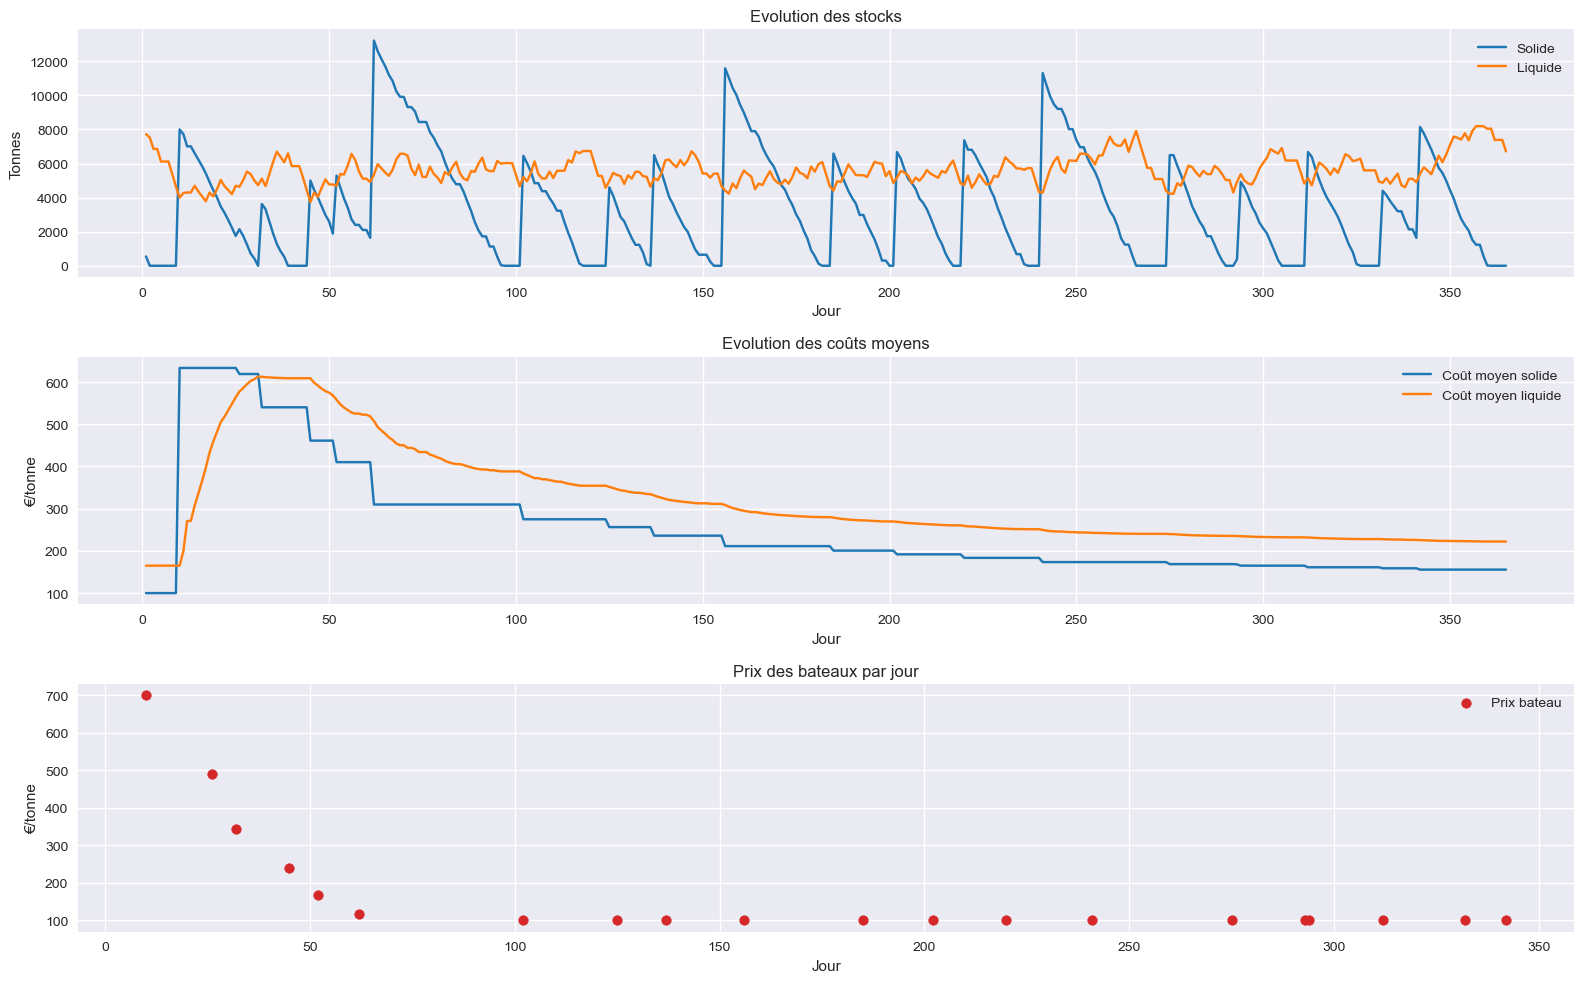

In [10]:
# Graphes d'evolution des prix
plt.figure(figsize=(16, 10))

# Stocks
plt.subplot(3, 1, 1)
plt.plot(results["jour"], results["stock_solide"], label='Solide', color='tab:blue')
plt.plot(results["jour"], results["stock_liquide"], label='Liquide', color='tab:orange')
plt.title('Evolution des stocks')
plt.xlabel('Jour')
plt.ylabel('Tonnes')
plt.legend()
plt.grid(True)

# Coûts moyens
plt.subplot(3, 1, 2)
plt.plot(results["jour"], results["cout_moyen_solide"], label='Coût moyen solide', color='tab:blue')
plt.plot(results["jour"], results["cout_moyen_liquide"], label='Coût moyen liquide', color='tab:orange')
plt.title('Evolution des coûts moyens')
plt.xlabel('Jour')
plt.ylabel('€/tonne')
plt.legend()
plt.grid(True)

# Prix des bateaux
plt.subplot(3, 1, 3)
if len(bateaux) > 0:
    plt.scatter(bateaux["jour"], bateaux["prix"], c='tab:red', label='Prix bateau')
    plt.title('Prix des bateaux par jour')
    plt.xlabel('Jour')
    plt.ylabel('€/tonne')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


## 5. Analyse des tailles de bateaux

In [11]:
if len(bateaux) > 0:
    tailles_counts = bateaux['quantite'].value_counts().sort_index()
    print('Repartition des tailles de bateaux:')
    for taille in TAILLES_BATEAUX:
        count = tailles_counts.get(taille, 0)
        pct = count / len(bateaux) * 100
        print(f'  {taille:>5}t : {count:>4} bateaux ({pct:>5.1f}%)')
    pct_5k_7k = (tailles_counts.get(5000, 0) + tailles_counts.get(7000, 0)) / len(bateaux) * 100
    print(f'\nBateaux 5000 ou 7000 : {pct_5k_7k:.1f}%')

Repartition des tailles de bateaux:
   1000t :    2 bateaux ( 10.0%)
   4000t :    2 bateaux ( 10.0%)
   5000t :    4 bateaux ( 20.0%)
   7000t :    7 bateaux ( 35.0%)
   8000t :    2 bateaux ( 10.0%)
  12000t :    3 bateaux ( 15.0%)

Bateaux 5000 ou 7000 : 55.0%


## 6. Graphiques

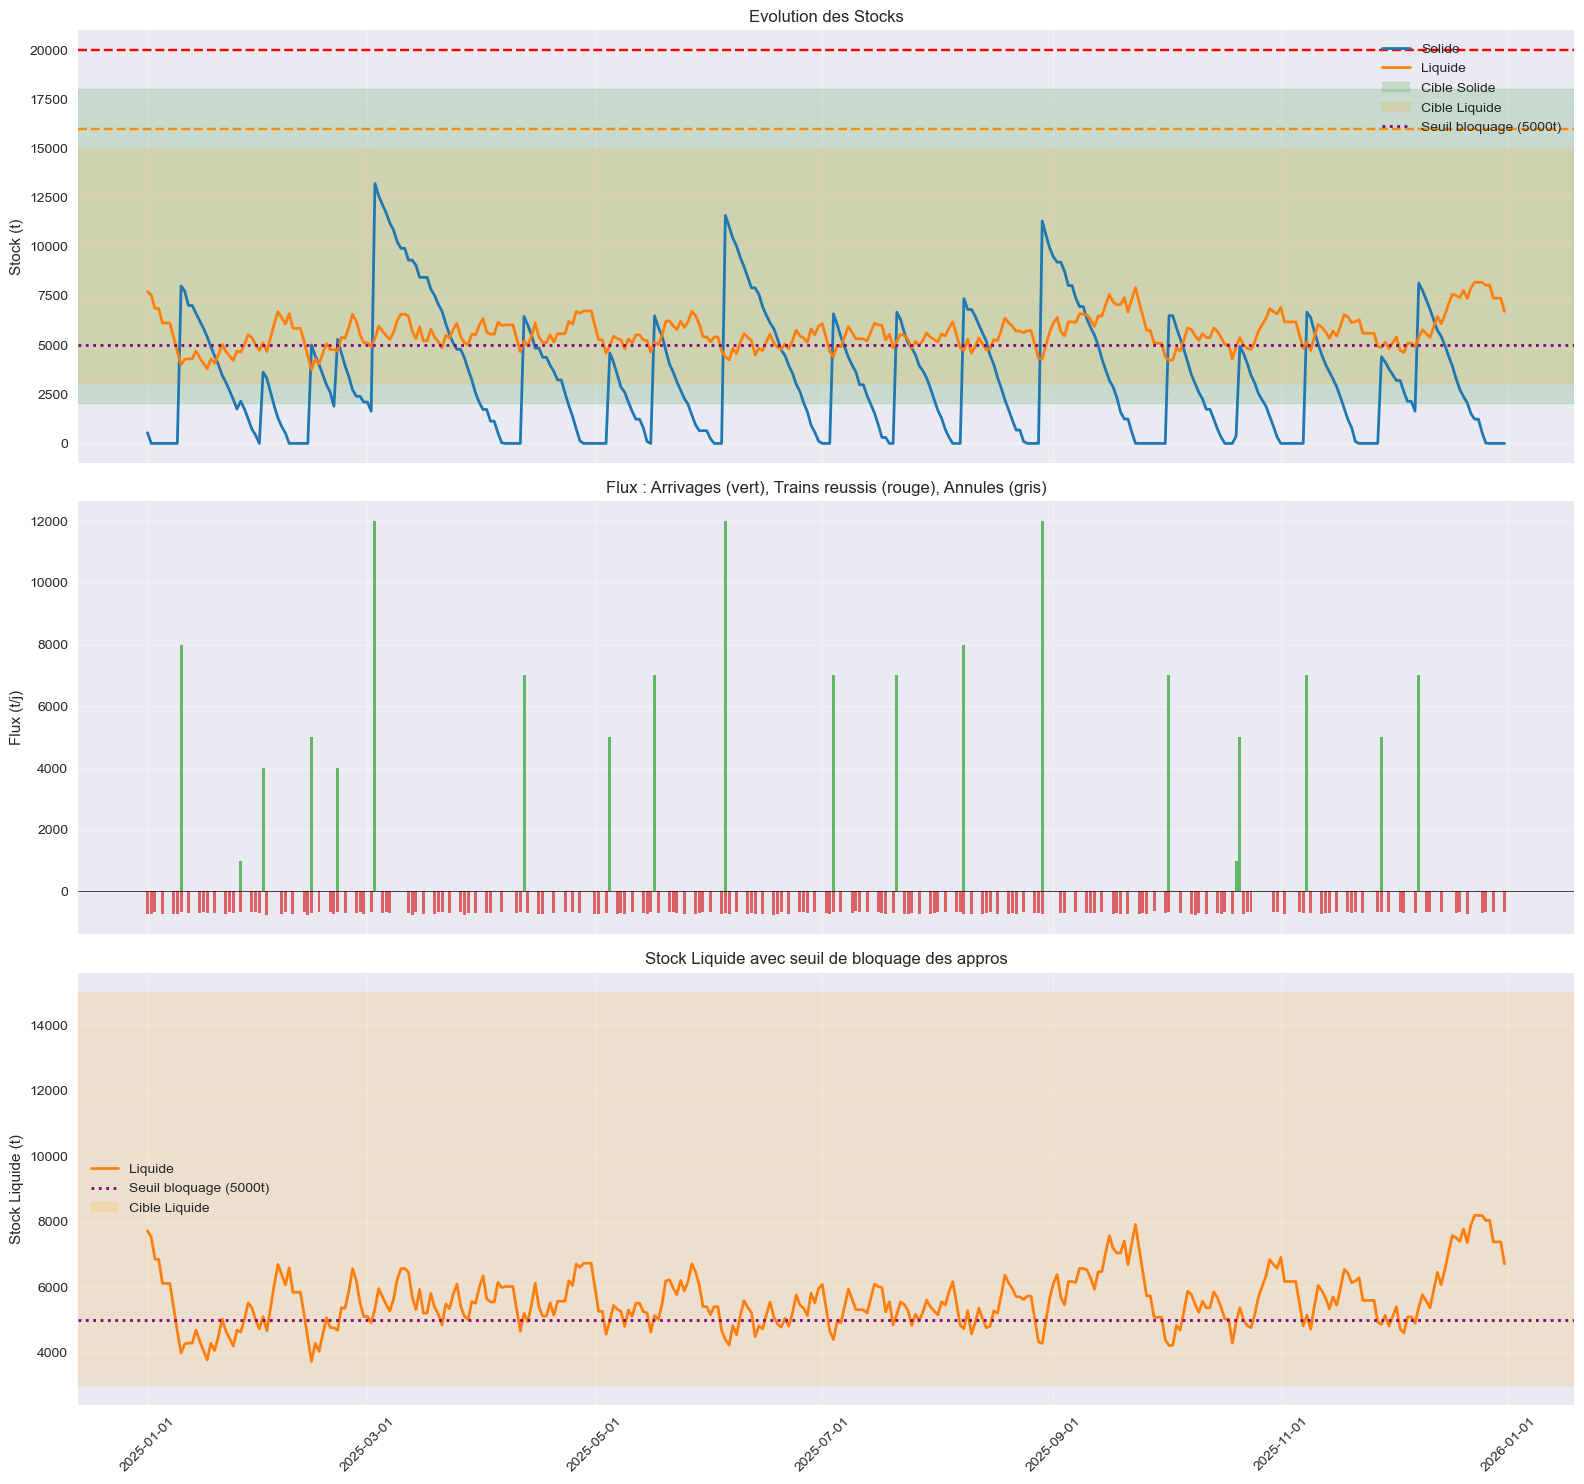

In [12]:
dates = pd.date_range(start='2025-01-01', periods=N_JOURS, freq='D')
results['date'] = dates
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 15), sharex=True)

# Stocks
ax1.plot(results['date'], results['stock_solide'], label='Solide', color='#1f77b4', linewidth=2)
ax1.plot(results['date'], results['stock_liquide'], label='Liquide', color='#ff7f0e', linewidth=2)
ax1.axhspan(STOCK_SOLIDE_MIN, STOCK_SOLIDE_MAX, color='green', alpha=0.15, label='Cible Solide')
ax1.axhspan(STOCK_LIQUIDE_MIN, STOCK_LIQUIDE_MAX, color='orange', alpha=0.15, label='Cible Liquide')
ax1.axhline(y=SEUIL_LIQUIDE_BLOQUE, color='purple', linestyle=':', linewidth=2, label=f'Seuil bloquage ({SEUIL_LIQUIDE_BLOQUE}t)')
ax1.axhline(y=CAPACITE_SOLIDE, color='red', linestyle='--')
ax1.axhline(y=CAPACITE_LIQUIDE, color='darkorange', linestyle='--')
ax1.set_ylabel('Stock (t)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title('Evolution des Stocks')

# Flux
for _, row in bateaux.iterrows():
    ax2.bar(dates[int(row['jour']) - 1], row['quantite'], color='#2ca02c', alpha=0.7, width=0.8)
for _, row in soutirages[soutirages['statut'] == 'reussi'].iterrows():
    ax2.bar(dates[row['jour'] - 1], -row['quantite'], color='#d62728', alpha=0.7, width=0.8)
for _, row in soutirages[soutirages['statut'] == 'annule'].iterrows():
    ax2.bar(dates[row['jour'] - 1], 0, color='#999999', alpha=0.3, width=0.8, edgecolor='black')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_ylabel('Flux (t/j)')
ax2.set_title('Flux : Arrivages (vert), Trains reussis (rouge), Annules (gris)')
ax2.grid(True, alpha=0.3)

# Detail du stock liquide avec seuil
ax3.plot(results['date'], results['stock_liquide'], label='Liquide', color='#ff7f0e', linewidth=2)
ax3.axhline(y=SEUIL_LIQUIDE_BLOQUE, color='purple', linestyle=':', linewidth=2, label=f'Seuil bloquage ({SEUIL_LIQUIDE_BLOQUE}t)')
ax3.axhspan(STOCK_LIQUIDE_MIN, STOCK_LIQUIDE_MAX, color='orange', alpha=0.15, label='Cible Liquide')
ax3.set_ylabel('Stock Liquide (t)')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_title('Stock Liquide avec seuil de bloquage des appros')

for ax in [ax1, ax2, ax3]:
    ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 7. Analyse complete

In [13]:
dans_cible_s = ((results['stock_solide'] >= STOCK_SOLIDE_MIN) & (results['stock_solide'] <= STOCK_SOLIDE_MAX)).sum()
dans_cible_l = ((results['stock_liquide'] >= STOCK_LIQUIDE_MIN) & (results['stock_liquide'] <= STOCK_LIQUIDE_MAX)).sum()
neg_l = (results['stock_liquide'] < 0).sum()
au_dessus_10k = (results['stock_liquide'] > SEUIL_LIQUIDE_BLOQUE).sum()
print(f'Solide dans cible: {dans_cible_s/N_JOURS*100:.1f}%')
print(f'Liquide dans cible: {dans_cible_l/N_JOURS*100:.1f}%')
print(f'Liquide > {SEUIL_LIQUIDE_BLOQUE}t: {au_dessus_10k} jours ({au_dessus_10k/N_JOURS*100:.1f}%)')
print(f'Liquide negatif: {neg_l} jours')
print(f'Trains: {(soutirages["statut"]=="reussi").sum()} reussis, {(soutirages["statut"]=="annule").sum()} annules')
print(f'Arrets fonte: {(debits == 0).sum()} jours')
print(f'Bateaux bloques: {bateaux_bloques}')

Solide dans cible: 59.2%
Liquide dans cible: 100.0%
Liquide > 5000t: 285 jours (78.1%)
Liquide negatif: 0 jours
Trains: 191 reussis, 18 annules
Arrets fonte: 39 jours
Bateaux bloques: 129


## 8. Facteur d'ajustement

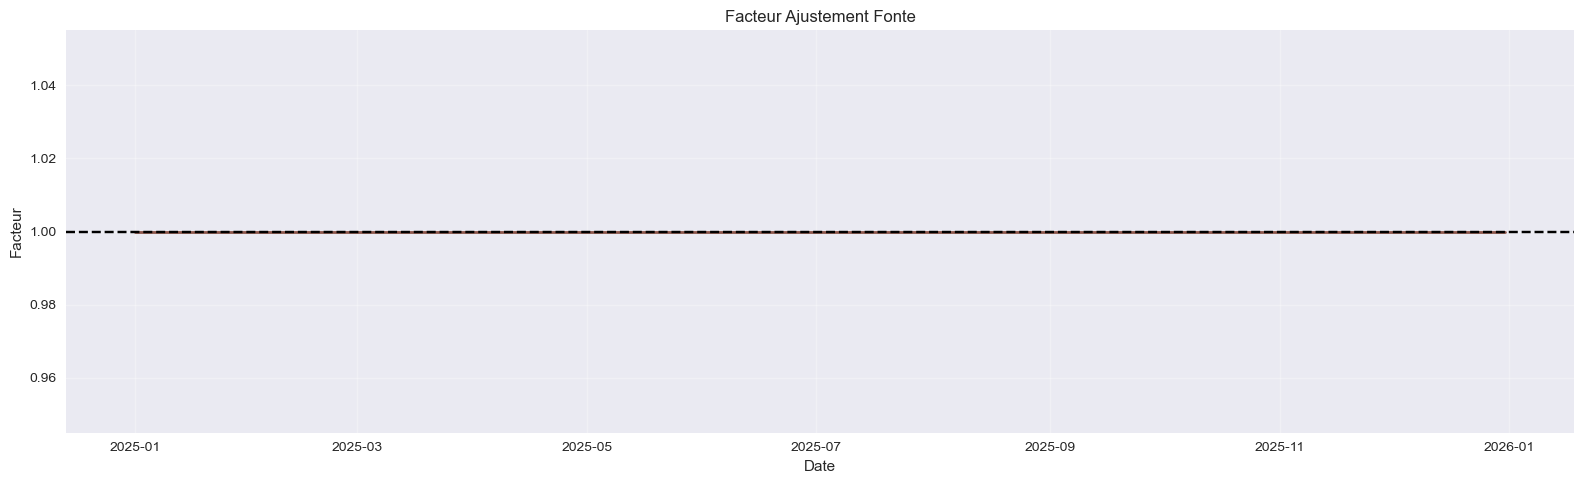

Facteur: moy=1.000, min=1.000, max=1.000


In [14]:
facteurs = [calculer_facteur_liquide(results['stock_liquide'].iloc[j-1]) for j in range(1, N_JOURS+1)]
plt.figure(figsize=(16, 5))
plt.plot(dates, facteurs, color='#8c564b', linewidth=2)
plt.axhline(y=1.0, color='black', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Facteur')
plt.title('Facteur Ajustement Fonte')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Facteur: moy={np.mean(facteurs):.3f}, min={np.min(facteurs):.3f}, max={np.max(facteurs):.3f}')

In [15]:
output_dir = './output_simulation'
os.makedirs(output_dir, exist_ok=True)
results.to_csv(f'{output_dir}/stocks.csv', index=False)
bateaux.to_csv(f'{output_dir}/bateaux.csv', index=False)
soutirages.to_csv(f'{output_dir}/trains.csv', index=False)
events.to_csv(f'{output_dir}/evenements.csv', index=False)
params = {'N_JOURS': N_JOURS, 'STOCK_SOLIDE_MIN': STOCK_SOLIDE_MIN, 'STOCK_SOLIDE_MAX': STOCK_SOLIDE_MAX,
          'STOCK_LIQUIDE_MIN': STOCK_LIQUIDE_MIN, 'STOCK_LIQUIDE_MAX': STOCK_LIQUIDE_MAX,
          'SEUIL_LIQUIDE_BLOQUE': SEUIL_LIQUIDE_BLOQUE,
          'TAILLES_BATEAUX': TAILLES_BATEAUX, 'PROBA_TAILLES': PROBA_TAILLES,
          'PROBA_ANNULATION_TRAIN': PROBA_ANNULATION_TRAIN, 'PROBA_ARRET_FONTE': PROBA_ARRET_FONTE}
with open(f'{output_dir}/parametres.json', 'w') as f:
    json.dump(params, f, indent=4)
print('Sauvegarde OK')

Sauvegarde OK
